# Retail Sales AnalysisEnd-to-end exploratory data analysis of a retail sales dataset, covering data cleaning, revenue/profit trends, product & regional performance, and RFM customer segmentation.**Tools:** Python (pandas, matplotlib, seaborn) + SQL (see `sql/analysis_queries.sql`)

## 1. Load & Clean DataThe raw data contains realistic messiness: inconsistent region casing, missing values, and duplicate rows.

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_style("whitegrid")plt.rcParams["figure.dpi"] = 110df = pd.read_csv("../data/retail_sales.csv", parse_dates=["order_date"])print(f"Raw rows: {len(df)}")df.head()

Raw rows: 6060

In [ ]:
# Normalize region text and fill missing valuesdf["region"] = df["region"].str.strip().str.title()df["customer_segment"] = df["customer_segment"].fillna("Unknown")df["discount"] = df["discount"].fillna(0)# Drop exact duplicatesbefore = len(df)df = df.drop_duplicates()print(f"Removed {before - len(df)} duplicate rows -> {len(df)} clean rows")df["month"] = df["order_date"].dt.to_period("M").astype(str)df["profit_margin"] = df["profit"] / df["total_sales"]

Removed 60 duplicate rows -> 6000 clean rows

## 2. Monthly Revenue & Profit Trend

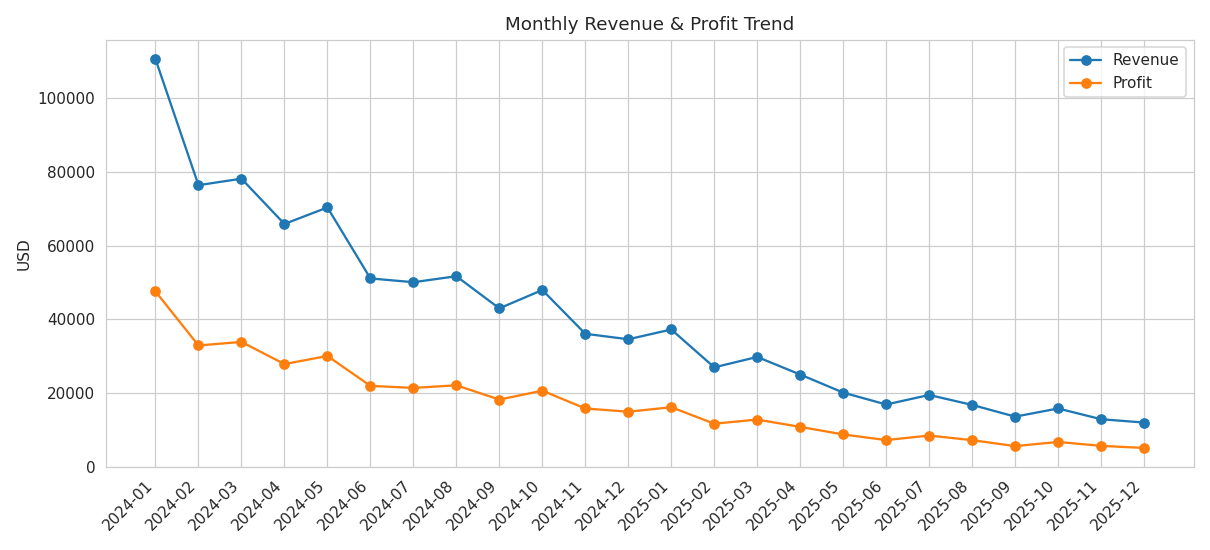

In [ ]:
monthly = df.groupby("month").agg(    revenue=("total_sales", "sum"),    profit=("profit", "sum"),    orders=("order_id", "nunique")).reset_index()plt.figure(figsize=(11, 5))plt.plot(monthly["month"], monthly["revenue"], marker="o", label="Revenue")plt.plot(monthly["month"], monthly["profit"], marker="o", label="Profit")plt.xticks(rotation=45, ha="right")plt.title("Monthly Revenue & Profit Trend")plt.ylabel("USD")plt.legend()plt.tight_layout()plt.show()

## 3. Top 10 Products by Revenue

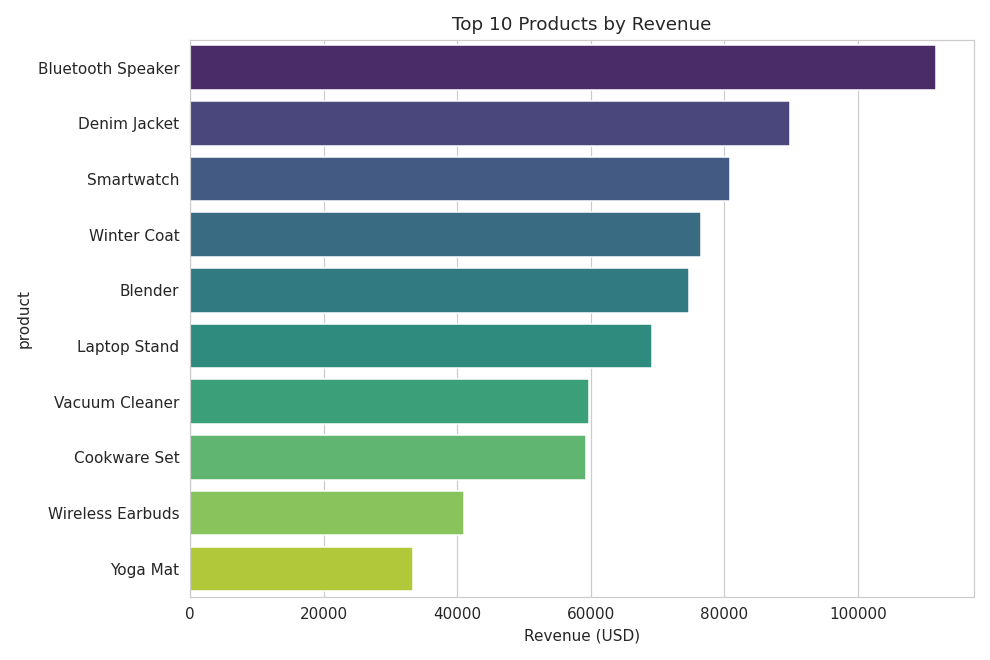

In [ ]:
top_products = df.groupby("product")["total_sales"].sum().sort_values(ascending=False).head(10)plt.figure(figsize=(9, 6))sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="viridis", legend=False)plt.title("Top 10 Products by Revenue")plt.xlabel("Revenue (USD)")plt.tight_layout()plt.show()

## 4. Regional Performance

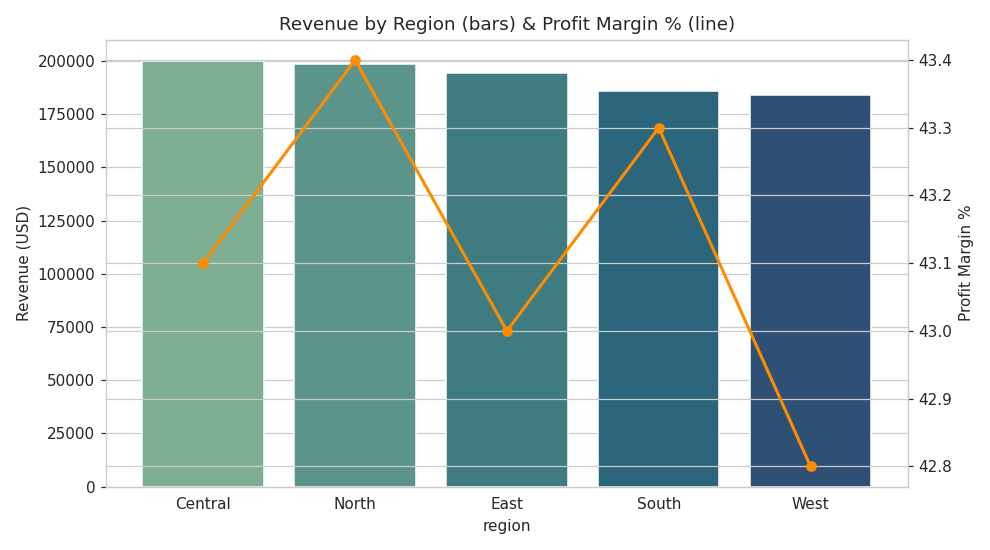

In [ ]:
region_perf = df.groupby("region").agg(revenue=("total_sales", "sum"), profit=("profit", "sum")).reset_index()region_perf["profit_margin_pct"] = (region_perf["profit"] / region_perf["revenue"] * 100).round(1)region_perf = region_perf.sort_values("revenue", ascending=False)fig, ax1 = plt.subplots(figsize=(9, 5))sns.barplot(data=region_perf, x="region", y="revenue", hue="region", palette="crest", legend=False, ax=ax1)ax1.set_ylabel("Revenue (USD)")ax1.set_title("Revenue by Region (bars) & Profit Margin % (line)")ax2 = ax1.twinx()ax2.plot(region_perf["region"], region_perf["profit_margin_pct"], color="darkorange", marker="o", linewidth=2)ax2.set_ylabel("Profit Margin %")plt.tight_layout()plt.show()

## 5. Category Profit Margins

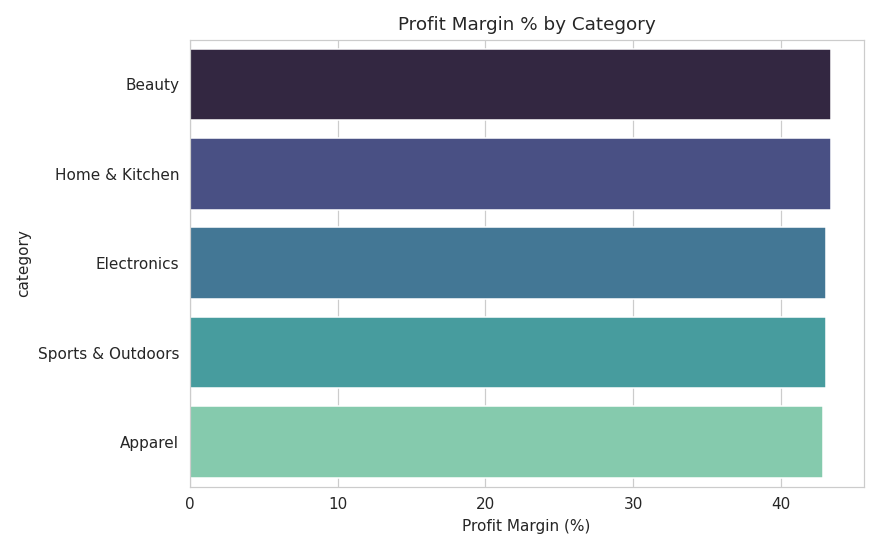

In [ ]:
cat_perf = df.groupby("category").agg(revenue=("total_sales", "sum"), profit=("profit", "sum")).reset_index()cat_perf["profit_margin_pct"] = (cat_perf["profit"] / cat_perf["revenue"] * 100).round(1)cat_perf = cat_perf.sort_values("profit_margin_pct", ascending=False)plt.figure(figsize=(8, 5))sns.barplot(data=cat_perf, x="profit_margin_pct", y="category", hue="category", palette="mako", legend=False)plt.title("Profit Margin % by Category")plt.xlabel("Profit Margin (%)")plt.tight_layout()plt.show()

## 6. Customer Segmentation (RFM Analysis)Segmenting customers by **Recency**, **Frequency**, and **Monetary** value using quartile scoring.

In [ ]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)rfm = df.groupby("customer_id").agg(    recency=("order_date", lambda x: (snapshot_date - x.max()).days),    frequency=("order_id", "nunique"),    monetary=("total_sales", "sum")).reset_index()rfm["r_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)rfm["m_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]def segment_customer(score):    if score >= 10: return "Champions"    elif score >= 8: return "Loyal"    elif score >= 6: return "Potential"    else: return "At Risk"rfm["segment"] = rfm["rfm_score"].apply(segment_customer)rfm["segment"].value_counts()

Champions    485\nAt Risk      447\nPotential    423\nLoyal        382\nName: segment, dtype: int64

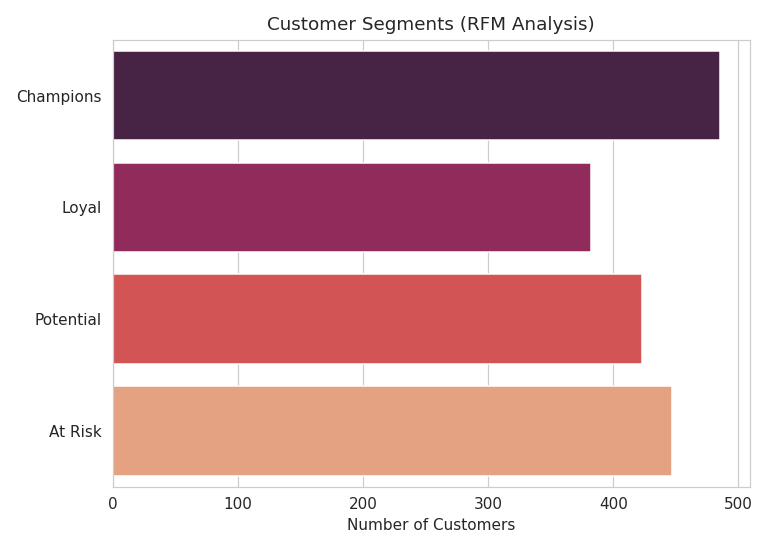

In [ ]:
seg_counts = rfm["segment"].value_counts()seg_order = ["Champions", "Loyal", "Potential", "At Risk"]plt.figure(figsize=(7, 5))sns.barplot(x=seg_counts.reindex(seg_order).values, y=seg_order, hue=seg_order, palette="rocket", legend=False)plt.title("Customer Segments (RFM Analysis)")plt.xlabel("Number of Customers")plt.tight_layout()plt.show()

## 7. Does Discounting Actually Help?Comparing average profit margin across discount bands.

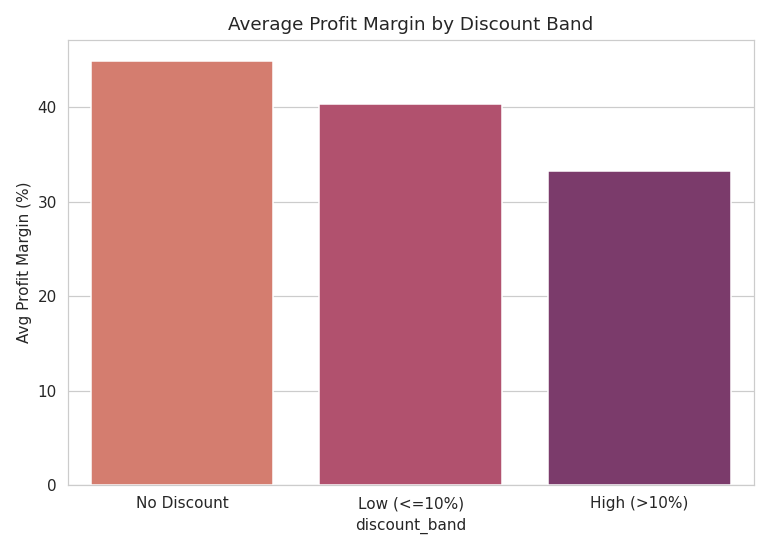

In [ ]:
def discount_band(d):    if d == 0: return "No Discount"    elif d <= 0.1: return "Low (<=10%)"    else: return "High (>10%)"df["discount_band"] = df["discount"].apply(discount_band)disc_margin = df.groupby("discount_band")["profit_margin"].mean().reindex(    ["No Discount", "Low (<=10%)", "High (>10%)"]) * 100plt.figure(figsize=(7, 5))sns.barplot(x=disc_margin.index, y=disc_margin.values, hue=disc_margin.index, palette="flare", legend=False)plt.title("Average Profit Margin by Discount Band")plt.ylabel("Avg Profit Margin (%)")plt.tight_layout()plt.show()

## 8. Key Findings- **Total revenue:** \$962,857.90  |  **Total profit:** \$415,047.75  |  **Overall margin:** 43.1%- **Top product:** Bluetooth Speaker (\$111,704 in revenue)- **Best-performing region:** Central (\$200,017 in revenue)- **Highest-margin category:** Beauty (43.4% margin)- **Discounting hurts margin:** orders with no discount average a 44.9% margin vs. 33.3% for orders discounted more than 10% — discounts are eating into profitability faster than they're driving volume.- **Customer base is fairly balanced** across RFM segments, but the "At Risk" segment (447 customers) represents a meaningful re-engagement opportunity — a targeted win-back campaign could recover significant lifetime value.### Recommendations1. Investigate whether high-discount promotions are necessary — consider capping standard discounts at 10%.2. Double down on marketing for the Central region and Beauty category, which show the best returns.3. Launch a re-engagement campaign (email/SMS offers) targeted at the "At Risk" customer segment before they churn entirely.